# CMASS Sample Tutorial

In this notebook, you will work directly with the **BOSS CMASS galaxy sample** — one of the most well-characterized galaxy samples in modern cosmology. CMASS (short for "constant mass") is a sample of massive, red, luminous galaxies at intermediate redshifts (z ≈ 0.4–0.7), selected from the BOSS spectroscopic survey.

By the end of this notebook, you will:
- Know how to load and inspect a real astronomical catalog in FITS format
- Understand what columns are available and what they mean physically
- Be able to plot the sky distribution of a galaxy sample
- Know how to convert fluxes to magnitudes and compute colors
- Be able to visualize and compare magnitude and color distributions

---

## A note on FITS files

Astronomical catalogs are typically stored in **FITS format** (Flexible Image Transport System). A FITS file can contain images, tables, and metadata. When we say "catalog," we mean a table where each row is a galaxy and each column is a measured property (position, brightness, redshift, etc.).

We'll use the `fitsio` package to read these files — it's fast and memory-efficient for large catalogs.

## 0. Import packages

We start by importing the Python packages we'll use throughout this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fitsio

# Make plots look nicer
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13

## 1. Load the CMASS catalog

The CMASS catalog is stored as a FITS file on OSC. We load it using `fitsio.read()`.

This returns a **structured numpy array** — think of it like a table where you can access each column by name.

In [2]:
cmass_filename = '/fs/ess/PHS0411/summer/cmass-dr12v4-S-Reid-full.dat.fits'

data = fitsio.read(cmass_filename)

print(f'Number of galaxies: {len(data):,}')

Number of galaxies: 258,884


### What columns are available?

Let's look at all the column names in the catalog.

In [3]:
print('Columns in the CMASS catalog:')
for col in data.dtype.names:
    print(f'  {col}')

Columns in the CMASS catalog:
  RA
  DEC
  RUN
  RERUN
  CAMCOL
  FIELD
  ID
  ICHUNK
  IPOLY
  ISECT
  FRACPSF
  EXPFLUX
  DEVFLUX
  PSFFLUX
  MODELFLUX
  FIBER2FLUX
  R_DEV
  EXTINCTION
  PSF_FWHM
  AIRMASS
  SKYFLUX
  EB_MINUS_V
  IMAGE_DEPTH
  IMATCH
  Z
  WEIGHT_FKP
  WEIGHT_CP
  WEIGHT_NOZ
  WEIGHT_STAR
  WEIGHT_SEEING
  WEIGHT_SYSTOT
  NZ
  COMP
  CP_COMP
  PLATE
  FIBERID
  MJD
  NTILES
  FINALN
  FINALID
  NASSIGNED
  WHICHFINAL
  TILE
  SPECTILE
  COLLATEINDX
  ICOLLIDED
  COLL_GROUP_FINALID
  COLL_GROUP_BOSSTARGET1
  INGROUP
  FIRSTGROUP
  MULTGROUP
  NEXTGROUP


Here are the columns we'll use in this tutorial and what they mean:

| Column | Description |
|--------|-------------|
| `RA`, `DEC` | Sky coordinates (Right Ascension and Declination, in degrees) |
| `Z` | Spectroscopic redshift — how fast the galaxy is moving away from us |
| `MODELFLUX` | Flux measured in 5 bands: **u, g, r, i, z** (in nanomaggies) |
| `EXTINCTION` | Dust extinction correction in 5 bands: **u, g, r, i, z** |

> **What is a nanomaggy?** Flux in astronomy is often measured in "maggies," a linear flux unit defined so that an object with flux 1 maggy has magnitude 0. A nanomaggy is 10⁻⁹ maggies. We'll convert these to the more familiar magnitude system below.

### Quick look at the data

Let's check the basic shape of the arrays we'll use.

In [4]:
print(f'MODELFLUX shape: {data["MODELFLUX"].shape}')   # (N galaxies, 5 bands)
print(f'EXTINCTION shape: {data["EXTINCTION"].shape}') # (N galaxies, 5 bands)
print(f'RA range: {data["RA"].min():.2f} – {data["RA"].max():.2f} deg')
print(f'DEC range: {data["DEC"].min():.2f} – {data["DEC"].max():.2f} deg')
print(f'Redshift range: {data["Z"].min():.3f} – {data["Z"].max():.3f}')

MODELFLUX shape: (258884, 5)
EXTINCTION shape: (258884, 5)
RA range: 0.00 – 360.00 deg
DEC range: -10.99 – 36.24 deg
Redshift range: -10.000 – 1.137


---

## 2. Sky distribution

The most basic thing we can plot is where on the sky these galaxies are. Each galaxy has a position given by **Right Ascension (RA)** and **Declination (Dec)** — the astronomical equivalent of longitude and latitude.

The full CMASS sample covers two separate regions of the sky: the **North Galactic Cap (NGC)** and the **South Galactic Cap (SGC)**. These are large patches of sky defined relative to the plane of the Milky Way. The NGC is significantly larger than the SGC.

**In this project, we use only the SGC.** This is the region that overlaps with the DES footprint, which is concentrated in the southern sky. Since DMASS is built from DES imaging, we need to compare it against the CMASS galaxies in the same part of the sky — the SGC.

The SGC spans roughly RA ~ 300° to 50° (crossing RA = 0°) and Dec ~ −10° to 25°.

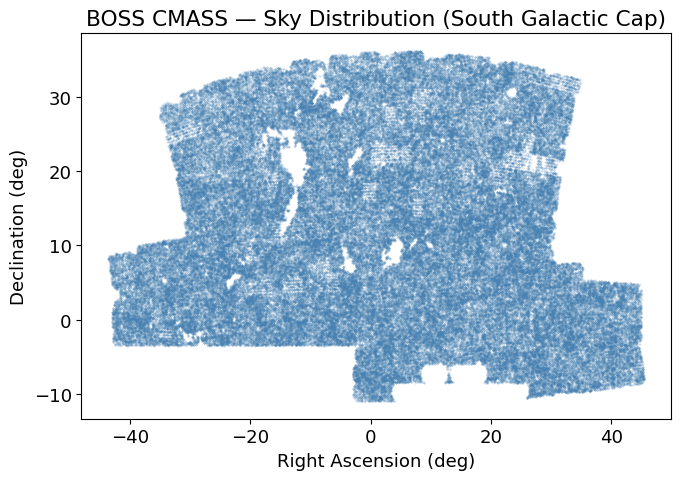

In [6]:
ra  = data['RA']
dec = data['DEC']

# The CMASS SGC footprint spans RA ~ 300 to 50 degrees, crossing RA=0.
# If we plot raw RA (0–360), the footprint gets split in two.
# Instead, we shift RA > 180 by subtracting 360, so the range becomes
# -180 to 180 and RA=0 sits in the middle — keeping the footprint contiguous.
ra_plot = np.where(ra > 180, ra - 360, ra)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(ra_plot, dec, s=0.1, alpha=0.3, color='steelblue', rasterized=True)

ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('BOSS CMASS — Sky Distribution (South Galactic Cap)')

plt.tight_layout()
plt.show()

> **Question 1:** The plot shows the BOSS survey footprint. Does it cover the whole sky? Why do you think a spectroscopic survey like BOSS only covers part of the sky?

> **Question 2:** Do you notice any structure in the distribution — areas that seem denser or sparser? What might cause that?

---

## 3. Redshift distribution

One of the key features of a spectroscopic survey like BOSS is that we know the **exact redshift** of every galaxy. The redshift tells us how far away the galaxy is — higher redshift means farther away.

CMASS is designed to target galaxies in the redshift range z ≈ 0.4–0.7. Let's verify this.

Galaxies with valid redshifts: 246,642


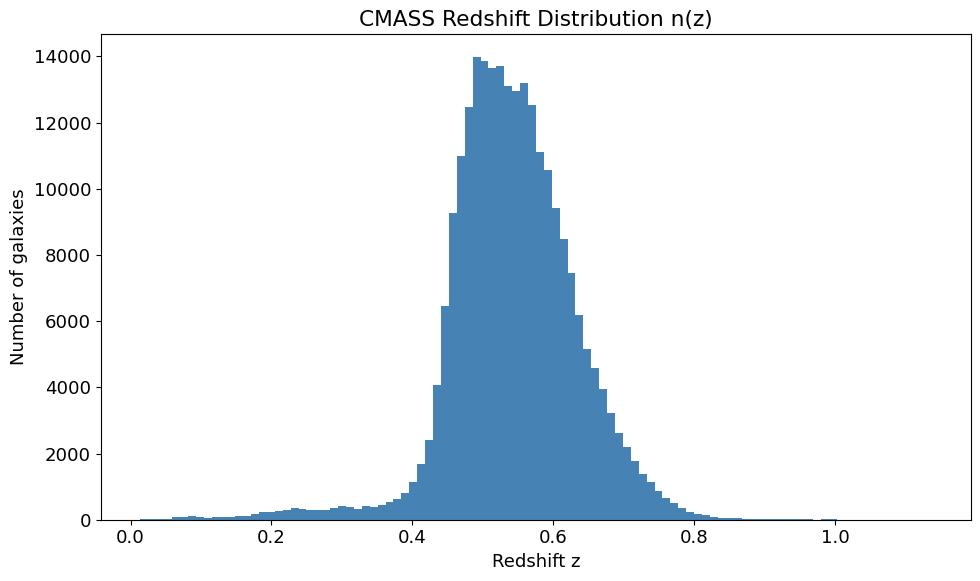

Median redshift: 0.540


In [8]:
z = data['Z']

# Some galaxies have z = -10, which indicates a redshift measurement failure
# (the spectrograph couldn't determine a reliable redshift for that object).
# We remove these before plotting.
z = z[z > 0.01]
print(f'Galaxies with valid redshifts: {len(z):,}')

fig, ax = plt.subplots()

ax.hist(z, bins=100, color='steelblue', edgecolor='none')

ax.set_xlabel('Redshift z')
ax.set_ylabel('Number of galaxies')
ax.set_title('CMASS Redshift Distribution n(z)')

plt.tight_layout()
plt.show()

print(f'Median redshift: {np.median(z):.3f}')

> **Question 3:** The redshift distribution has a characteristic shape — it rises and then falls. Why doesn't it just increase or stay flat? Think about what physical and observational effects might shape this distribution.

---

## 4. From fluxes to magnitudes

Astronomers measure the brightness of objects in two ways:

- **Flux** — the actual amount of light received, in physical units (here: nanomaggies)
- **Magnitude** — a logarithmic scale where brighter objects have *smaller* (or more negative) magnitudes

The conversion from flux (in nanomaggies) to magnitude is:

$$m = 22.5 - 2.5 \log_{10}(f)$$

where $f$ is the flux in nanomaggies.

We also need to correct for **dust extinction** — dust in our own Milky Way absorbs some light from distant galaxies, making them look fainter than they really are. The `EXTINCTION` column gives the amount of dimming in each band, already in magnitudes, so we just subtract it:

$$m_{\rm corrected} = m_{\rm observed} - {\rm extinction}$$

The 5 bands are ordered **u, g, r, i, z** (indices 0–4).

In [9]:
flux       = data['MODELFLUX']      # shape (N, 5) — u,g,r,i,z
extinction = data['EXTINCTION']     # shape (N, 5) — u,g,r,i,z

# Convert flux to magnitude
# Clip flux at a small positive value to avoid log(0) errors
flux_clipped = np.clip(flux, 1e-6, None)
mag = 22.5 - 2.5 * np.log10(flux_clipped)

# Apply extinction correction
mag_corrected = mag - extinction

# Extract individual bands for convenience
mag_u = mag_corrected[:, 0]
mag_g = mag_corrected[:, 1]
mag_r = mag_corrected[:, 2]
mag_i = mag_corrected[:, 3]
mag_z = mag_corrected[:, 4]

print('Magnitude statistics (extinction-corrected):')
for name, m in zip(['u','g','r','i','z'], [mag_u, mag_g, mag_r, mag_i, mag_z]):
    print(f'  {name}-band:  mean = {np.mean(m):.2f},  std = {np.std(m):.2f}')

Magnitude statistics (extinction-corrected):
  u-band:  mean = 28.16,  std = 6.78
  g-band:  mean = 22.00,  std = 0.70
  r-band:  mean = 20.39,  std = 0.50
  i-band:  mean = 19.41,  std = 0.42
  z-band:  mean = 19.01,  std = 0.78


---

## 5. Magnitude distributions

Now let's plot the distribution of galaxy brightnesses in each band. CMASS targets **luminous** galaxies, so we expect them to be relatively bright (low magnitude values).

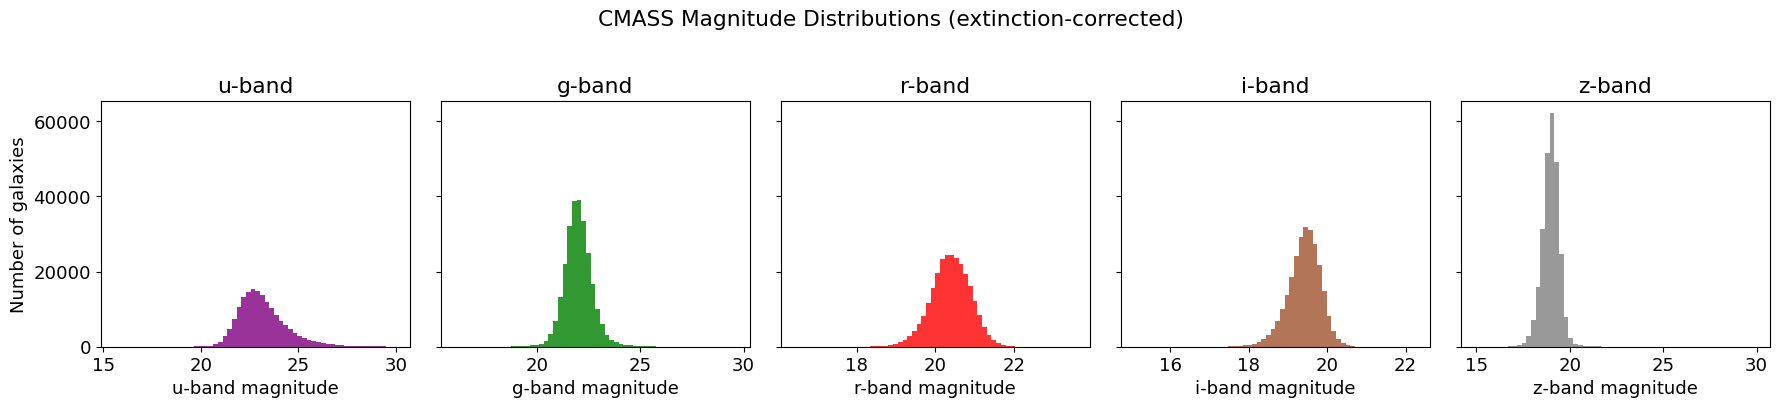

In [10]:
bands  = ['u', 'g', 'r', 'i', 'z']
mags   = [mag_u, mag_g, mag_r, mag_i, mag_z]
colors = ['purple', 'green', 'red', 'sienna', 'gray']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, band, m, c in zip(axes, bands, mags, colors):
    # Only plot galaxies with reasonable magnitudes
    mask = (m > 10) & (m < 30)
    ax.hist(m[mask], bins=60, color=c, alpha=0.8, edgecolor='none')
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_title(f'{band}-band')

axes[0].set_ylabel('Number of galaxies')
fig.suptitle('CMASS Magnitude Distributions (extinction-corrected)', y=1.02)

plt.tight_layout()
plt.show()

> **Question 4:** The distributions look different across bands. Which band shows the sharpest cutoff at the faint end? Why might a survey impose a magnitude limit?

> **Question 5:** The u-band distribution looks different from the others — wider, and potentially noisier. Why might u-band measurements be less reliable for red galaxies like CMASS?

---

## 6. Colors

A galaxy's **color** is simply the difference in magnitude between two bands:

$$\text{color} = m_{\rm band1} - m_{\rm band2}$$

Because magnitudes are on a logarithmic scale, a color measures the *ratio* of fluxes between two bands — in other words, the shape of the galaxy's spectrum.

- A **red galaxy** emits more light at long wavelengths (r, i, z) than short ones (u, g), so it has large positive colors like g−r or r−i.
- A **blue galaxy** has more light at short wavelengths, giving smaller (or negative) colors.

CMASS galaxies are massive, old, red galaxies — they sit on the **red sequence**. We expect them to have large g−r and r−i colors.

In [11]:
# Compute colors
color_gr = mag_g - mag_r
color_ri = mag_r - mag_i
color_iz = mag_i - mag_z

print('Color statistics:')
for name, c in zip(['g-r', 'r-i', 'i-z'], [color_gr, color_ri, color_iz]):
    mask = np.isfinite(c)
    print(f'  {name}:  mean = {np.mean(c[mask]):.3f},  std = {np.std(c[mask]):.3f}')

Color statistics:
  g-r:  mean = 1.611,  std = 0.445
  r-i:  mean = 0.981,  std = 0.172
  i-z:  mean = 0.404,  std = 0.649


### Color distributions

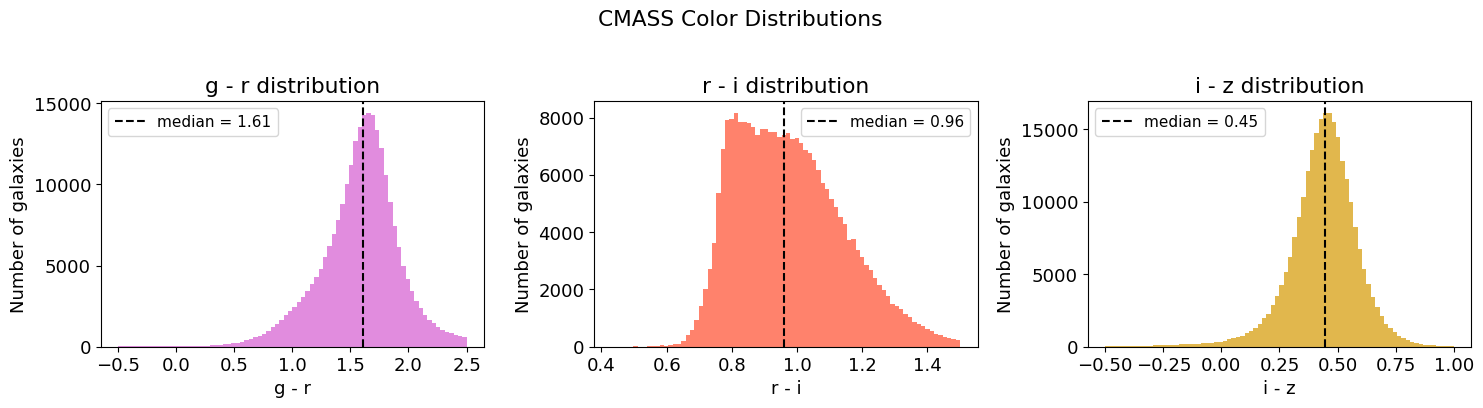

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

color_data = [color_gr, color_ri, color_iz]
color_names = ['g - r', 'r - i', 'i - z']
xlims = [(-0.5, 2.5), (-0.5, 1.5), (-0.5, 1.0)]
plot_colors = ['orchid', 'tomato', 'goldenrod']

for ax, c, name, xlim, pc in zip(axes, color_data, color_names, xlims, plot_colors):
    mask = np.isfinite(c) & (c > xlim[0]) & (c < xlim[1])
    ax.hist(c[mask], bins=80, color=pc, alpha=0.8, edgecolor='none')
    ax.set_xlabel(name)
    ax.set_ylabel('Number of galaxies')
    ax.set_title(f'{name} distribution')
    ax.axvline(np.median(c[mask]), color='k', linestyle='--', linewidth=1.5, label=f'median = {np.median(c[mask]):.2f}')
    ax.legend(fontsize=11)

fig.suptitle('CMASS Color Distributions', y=1.02)
plt.tight_layout()
plt.show()

> **Question 6:** The g−r color distribution is quite broad. What does this tell us about the diversity of galaxies in the CMASS sample?

> **Question 7:** Compare the widths of the g−r, r−i, and i−z distributions. Which is the narrowest? What might this imply about how tightly CMASS selects galaxies in that color?

### Color-color diagram

A **color-color diagram** plots one color against another. This is a powerful tool for separating different types of galaxies — and for understanding how a sample like CMASS is selected.

We'll plot r−i vs. g−r. Red sequence galaxies form a tight locus in this space.

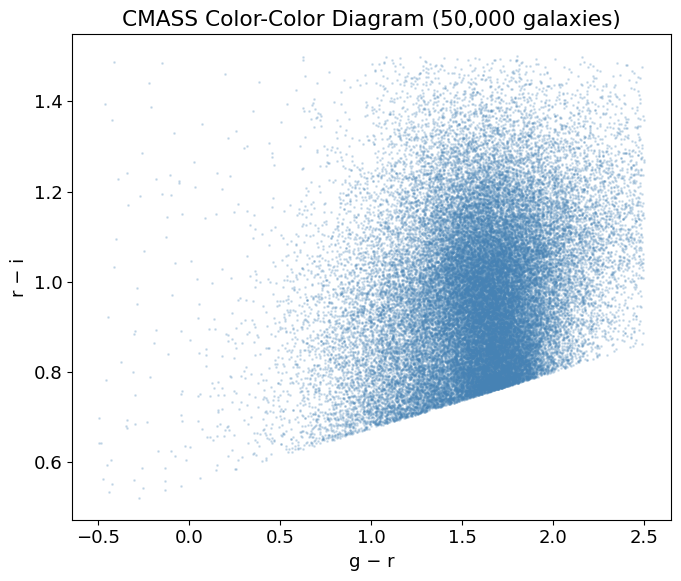

In [13]:
# Use a random subset for speed
rng  = np.random.default_rng(42)
idx  = rng.choice(len(data), size=50000, replace=False)

gr = color_gr[idx]
ri = color_ri[idx]

# Mask out unreasonable values
mask = (gr > -0.5) & (gr < 2.5) & (ri > -0.5) & (ri < 1.5)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(gr[mask], ri[mask], s=1, alpha=0.2, color='steelblue', rasterized=True)

ax.set_xlabel('g − r')
ax.set_ylabel('r − i')
ax.set_title('CMASS Color-Color Diagram (50,000 galaxies)')

plt.tight_layout()
plt.show()

> **Question 8:** Do you see a concentrated locus of points, or are galaxies spread out uniformly? What does this tell you about the CMASS selection?

> **Question 9:** If you were designing a color cut to select red galaxies, what cut would you draw on this diagram?

---

## Summary

In this notebook you have:

- Loaded a real spectroscopic galaxy catalog in FITS format
- Plotted the sky footprint of the BOSS survey
- Examined the redshift distribution of CMASS galaxies
- Converted fluxes to extinction-corrected magnitudes
- Plotted magnitude and color distributions
- Made a color-color diagram